In [1]:
import os
dataset_path = os.getcwd()

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Look for CSV files
metadata_files = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith((".csv", ".txt", ".json")):
            metadata_files.append(os.path.join(root, file))

print("\n CSV files found:")
for f in metadata_files:
        print("-", f)



 CSV files found:
- C:\Users\Zayd_\Desktop\TEST DEMO\COE49413-S25-Group-1\Project\csvTestImages 3360x1024.csv
- C:\Users\Zayd_\Desktop\TEST DEMO\COE49413-S25-Group-1\Project\csvTestLabel 3360x1.csv
- C:\Users\Zayd_\Desktop\TEST DEMO\COE49413-S25-Group-1\Project\csvTrainImages 13440x1024.csv
- C:\Users\Zayd_\Desktop\TEST DEMO\COE49413-S25-Group-1\Project\csvTrainLabel 13440x1.csv
- C:\Users\Zayd_\Desktop\TEST DEMO\COE49413-S25-Group-1\Project\Arabic Handwritten Characters Dataset CSV\csvTestImages 3360x1024.csv
- C:\Users\Zayd_\Desktop\TEST DEMO\COE49413-S25-Group-1\Project\Arabic Handwritten Characters Dataset CSV\csvTestLabel 3360x1.csv
- C:\Users\Zayd_\Desktop\TEST DEMO\COE49413-S25-Group-1\Project\Arabic Handwritten Characters Dataset CSV\csvTrainImages 13440x1024.csv
- C:\Users\Zayd_\Desktop\TEST DEMO\COE49413-S25-Group-1\Project\Arabic Handwritten Characters Dataset CSV\csvTrainLabel 13440x1.csv


In [4]:
# List top-level files and folders
top_files = os.listdir(dataset_path)
print("Top-level contents of the dataset folder:")
for f in top_files:
    print("-", f)


Top-level contents of the dataset folder:
- .ipynb_checkpoints
- Arabic Handwritten Characters Dataset CSV
- csvTestImages 3360x1024.csv
- csvTestLabel 3360x1.csv
- csvTrainImages 13440x1024.csv
- csvTrainLabel 13440x1.csv
- cv_project_code.ipynb
- cv_project_code_test_run.ipynb
- early_birds_model.h5
- early_birds_model_less_complex.h5
- Literature Review Conference Papers
- Project Syllabus.pdf
- Test Images 3360x32x32
- Train Images 13440x32x32
- Train+Test Images Matlab.mat


In [5]:
# Define folder paths
folder1_train = "./Train Images 13440x32x32/train"

folder1_test = "./Test Images 3360x32x32/test"

# Count files
def count_files(folder):
    return len([f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))])

print("Train folder 1 file count:", count_files(folder1_train))

print("Test folder 1 file count:", count_files(folder1_test))

# Compare file names
train_files_1 = set(os.listdir(folder1_train))
test_files_1 = set(os.listdir(folder1_test))

Train folder 1 file count: 13440
Test folder 1 file count: 3360


In [6]:
import pandas as pd

# Load training data
x_train = pd.read_csv("./csvTrainImages 13440x1024.csv", header=None)
y_train = pd.read_csv("./csvTrainLabel 13440x1.csv", header=None)

# Load testing data
x_test = pd.read_csv("./csvTestImages 3360x1024.csv", header=None)
y_test = pd.read_csv("./csvTestLabel 3360x1.csv", header=None)

In [7]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13440 entries, 0 to 13439
Columns: 1024 entries, 0 to 1023
dtypes: int64(1024)
memory usage: 105.0 MB


In [8]:
y_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13440 entries, 0 to 13439
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       13440 non-null  int64
dtypes: int64(1)
memory usage: 105.1 KB


In [9]:
# Create a summary table
data_summary = {
    "Dataset Part": ["x_train", "y_train", "x_test", "y_test"],
    "Shape (Rows x Columns)": [
        x_train.shape,
        y_train.shape,
        x_test.shape,
        y_test.shape
    ],
    "Description": [
        "Training images (flattened 32x32)",
        "Training labels",
        "Testing images (flattened 32x32)",
        "Testing labels"
    ]
}

summary_df = pd.DataFrame(data_summary)

# Display the summary table
print("📋 Dataset Overview:\n")
print(summary_df.to_markdown(index=False))


📋 Dataset Overview:

| Dataset Part   | Shape (Rows x Columns)   | Description                       |
|:---------------|:-------------------------|:----------------------------------|
| x_train        | (13440, 1024)            | Training images (flattened 32x32) |
| y_train        | (13440, 1)               | Training labels                   |
| x_test         | (3360, 1024)             | Testing images (flattened 32x32)  |
| y_test         | (3360, 1)                | Testing labels                    |


In [10]:
num_classes = y_train[0].nunique()
print("Number of unique classes (Arabic letters):", num_classes)

Number of unique classes (Arabic letters): 28


In [11]:
label_names = sorted(y_train[0].unique())
print("Unique label values:")
print(label_names)

Unique label values:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


In [12]:
label_counts = y_train[0].value_counts().sort_index()
print("Class distribution in training data:")
print(label_counts)

Class distribution in training data:
0
1     480
2     480
3     480
4     480
5     480
6     480
7     480
8     480
9     480
10    480
11    480
12    480
13    480
14    480
15    480
16    480
17    480
18    480
19    480
20    480
21    480
22    480
23    480
24    480
25    480
26    480
27    480
28    480
Name: count, dtype: int64


In [13]:
dataset_parts = {
    "x_train": x_train,
    "x_test": x_test,
    "y_train": y_train,
    "y_test": y_test
}

#determine if mapping is needed
def should_apply_mapping(data):
    # If all values are integers in 1 to 28, it's probably label data
    if pd.api.types.is_integer_dtype(data.values) and data.min().values[0] >= 1 and data.max().values[0] <= 28:
        return "Yes"
    else:
        return "No"

# summary table
rows = []
for name, df in dataset_parts.items():
    data_type = "Image data (pixels)" if df.shape[1] > 1 else "Numeric labels (1–28)"
    mapping_needed = should_apply_mapping(df)
    rows.append([name, data_type, mapping_needed])

# Create DataFrame
mapping_df = pd.DataFrame(rows, columns=["Data", "Type", "Apply Arabic Letter Mapping?"])

# Display as markdown table
print("Auto Analysis: Should We Map Labels?\n")
print(mapping_df.to_markdown(index=False))


Auto Analysis: Should We Map Labels?

| Data    | Type                  | Apply Arabic Letter Mapping?   |
|:--------|:----------------------|:-------------------------------|
| x_train | Image data (pixels)   | No                             |
| x_test  | Image data (pixels)   | No                             |
| y_train | Numeric labels (1–28) | Yes                            |
| y_test  | Numeric labels (1–28) | Yes                            |


Observation:

This table was generated by checking the shape and values of each dataset component.

Only label columns (y_train and y_test) contain integer values between 1 and 28, so they are eligible for mapping. Image data (x_train and x_test) contains multiple columns of pixel intensities, which should not be mapped.

In [15]:
print("Min label:", y_train[0].min())
print("Max label:", y_train[0].max())
print("Unique labels:", y_train[0].unique())

Min label: 1
Max label: 28
Unique labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28]


In [16]:
# Arabic letters in order (total of 28 letters)
arabic_letters = [
    "ا", "ب", "ت", "ث", "ج", "ح", "خ", "د", "ذ", "ر",
    "ز", "س", "ش", "ص", "ض", "ط", "ظ", "ع", "غ", "ف",
    "ق", "ك", "ل", "م", "ن", "هـ", "و", "ي"
]

# Create mapping dictionary
label_to_letter = {i + 1: letter for i, letter in enumerate(arabic_letters)}

# Apply mapping to y_train and y_test
y_train_letters = y_train[0].map(label_to_letter)
y_test_letters = y_test[0].map(label_to_letter)

# Display mapped sample
print("\n Sample mapped Arabic letters from y_train:")
print(y_train_letters.head(10))



 Sample mapped Arabic letters from y_train:
0    ا
1    ا
2    ا
3    ا
4    ا
5    ا
6    ا
7    ا
8    ب
9    ب
Name: 0, dtype: object


In [17]:
# Show one sample from each class after mapping
print("One sample letter for each class (1–28):")
sample_per_class = y_train[0].drop_duplicates().map(label_to_letter)
print(sample_per_class.reset_index(drop=True))

One sample letter for each class (1–28):
0      ا
1      ب
2      ت
3      ث
4      ج
5      ح
6      خ
7      د
8      ذ
9      ر
10     ز
11     س
12     ش
13     ص
14     ض
15     ط
16     ظ
17     ع
18     غ
19     ف
20     ق
21     ك
22     ل
23     م
24     ن
25    هـ
26     و
27     ي
Name: 0, dtype: object


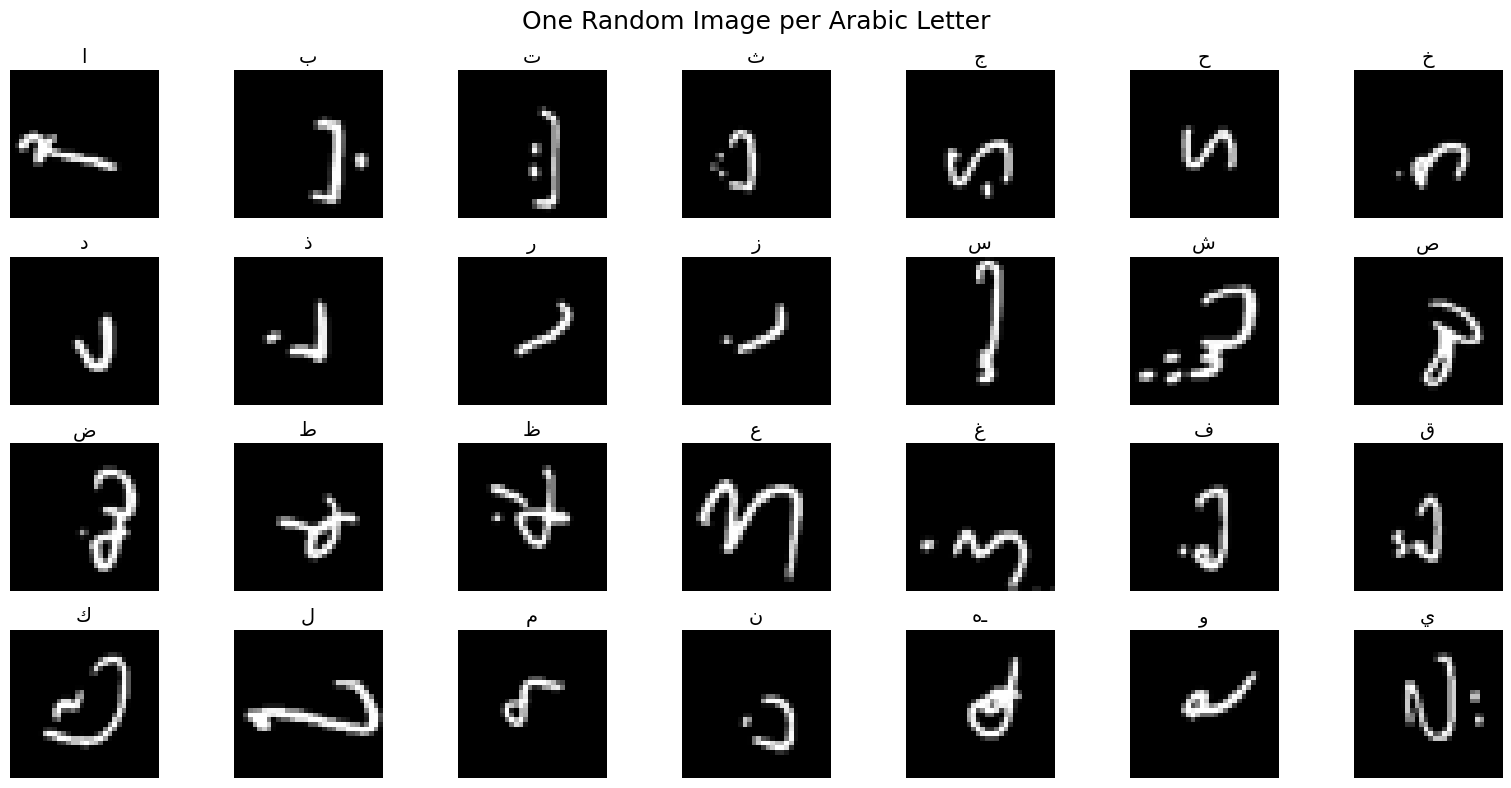

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure y_train_letters exists
y_train_letters = y_train[0].map(label_to_letter)

# Create a DataFrame combining x_train and y_train_letters
df = x_train.copy()
df["label"] = y_train_letters

# Convert all pixel values to integers
df.iloc[:, :-1] = df.iloc[:, :-1].apply(pd.to_numeric)

# Get one random sample per unique letter
sampled_df = df.groupby("label").sample(n=1, random_state=42)

# Plot
plt.figure(figsize=(16, 8))
for i, (idx, row) in enumerate(sampled_df.iterrows()):
    img = row[:-1].values.astype(np.uint8).reshape(32, 32)  # Convert to uint8
    label = row["label"]
    plt.subplot(4, 7, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{label}", fontsize=14)
    plt.axis("off")

plt.suptitle("One Random Image per Arabic Letter", fontsize=18)
plt.tight_layout()
plt.show()


The visual diversity in handwriting is noticeable .
- Some letters (like `ح`, `خ`, and `ج`) may appear visually similar, which could make classification more challenging.
- These samples confirm that the dataset includes a full set of Arabic characters, and that label-to-letter mapping is working correctly.

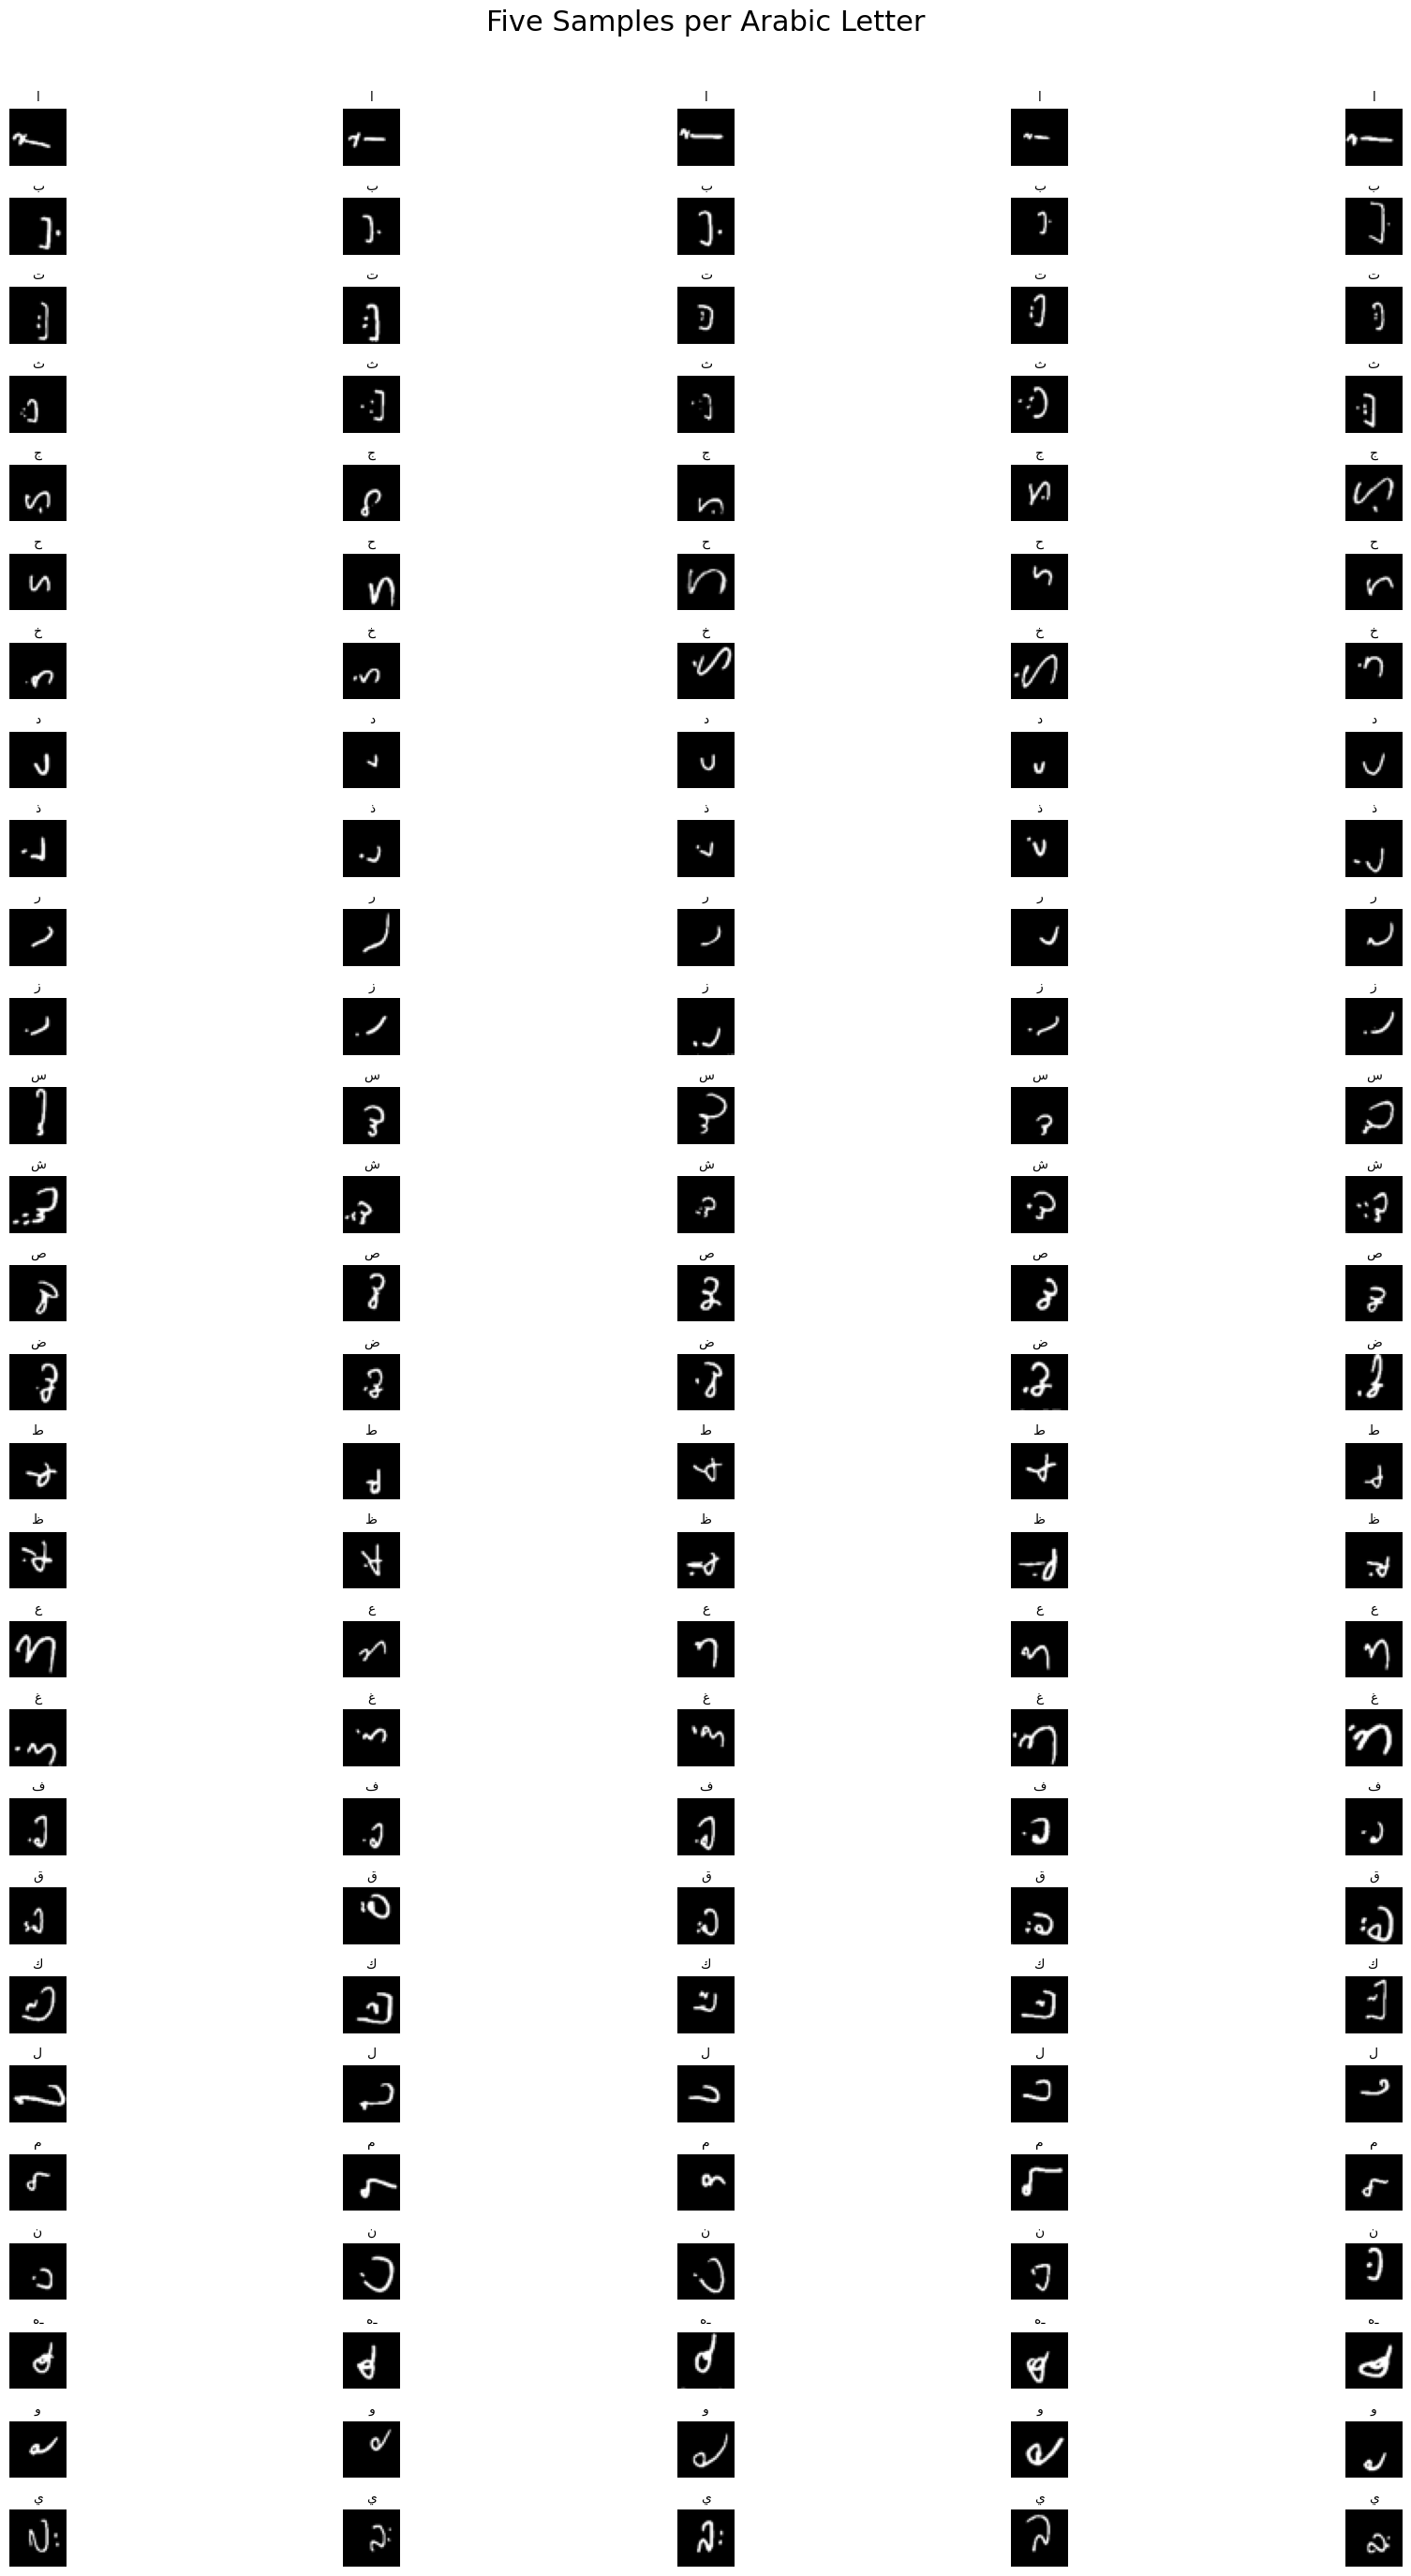

In [20]:
# Group by letter and sample 5 instances from each class
sampled_df = df.groupby("label").sample(n=5, random_state=42).reset_index(drop=True)

# Plot 5 samples per class (total 28x5 = 140 images)
plt.figure(figsize=(20, 28))
for i, (idx, row) in enumerate(sampled_df.iterrows()):
    img = row[:-1].astype(np.uint8).values.reshape(32, 32)
    label = row["label"]
    plt.subplot(28, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(label, fontsize=10)
    plt.axis("off")

plt.suptitle("Five Samples per Arabic Letter", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


# **Preprocessing**

In [22]:
!pip install tensorflow

In [23]:
# Normalize pixel values to [0, 1]
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

In [24]:
from tensorflow.keras.utils import to_categorical

# Convert class labels (1–28) to zero-based index (0–27)
y_train_adj = y_train[0] - 1
y_test_adj = y_test[0] - 1

# One-hot encode
y_train_oh = to_categorical(y_train_adj, num_classes=28)
y_test_oh = to_categorical(y_test_adj, num_classes=28)

In [25]:
# Reshape flattened 1024 vectors into 32x32 grayscale images
x_train_reshaped = x_train_norm.values.reshape(-1, 32, 32, 1)
x_test_reshaped = x_test_norm.values.reshape(-1, 32, 32, 1)

In [26]:
from sklearn.model_selection import train_test_split

# Stratified split from training set into train/val
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train_reshaped, y_train_oh, test_size=0.2, stratify=y_train_adj, random_state=42
)

80% → actual training (x_train_final)

20% → validation (x_val)

In [28]:
# Check shapes
print("Train shape:", x_train_final.shape)
print("Val shape:", x_val.shape)

Train shape: (10752, 32, 32, 1)
Val shape: (2688, 32, 32, 1)


Data is correctly split (80/20), reshaped to (32, 32, 1).

In [30]:
# Value range check
print("Pixel range:", x_train_final.min(), "to", x_train_final.max())

Pixel range: 0.0 to 1.0


In [31]:
# Label check
print("Example one-hot label:", y_train_final[0])
print("One-hot sums (should all be 1):", y_train_final.sum(axis=1)[:5])

Example one-hot label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
One-hot sums (should all be 1): [1. 1. 1. 1. 1.]


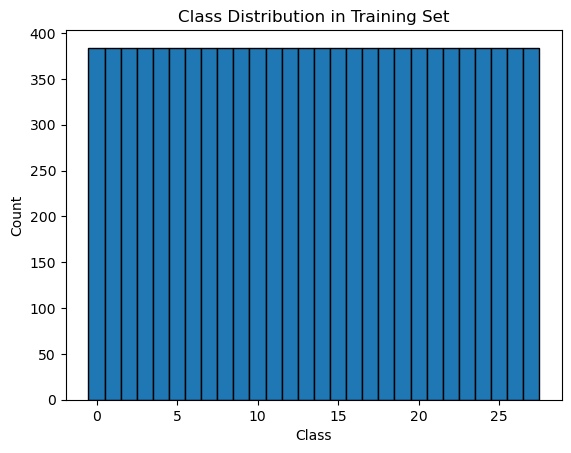

In [32]:
# Class balance
import numpy as np
import matplotlib.pyplot as plt

labels = np.argmax(y_train_final, axis=1)
plt.hist(labels, bins=np.arange(29)-0.5, edgecolor="black")
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The class distribution is as expected, with a balanced set of classes in the training data.

# **Data Augmentation**

In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize the ImageDataGenerator with the specified augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=10,        # Simulates tilt in handwriting
    width_shift_range=0.1,    # Mimics left/right writing variations
    height_shift_range=0.1,   # Captures top/bottom misalignments
    shear_range=0.1,          # Adds slant variability
    zoom_range=0.1,           # Simulates zoomed-in or out strokes
    horizontal_flip=False,    # Arabic characters are directional
    vertical_flip=False       # Arabic has no upside-down variation
)

# Fit the datagen on the training data (this step is necessary for certain augmentations)
datagen.fit(x_train_final)


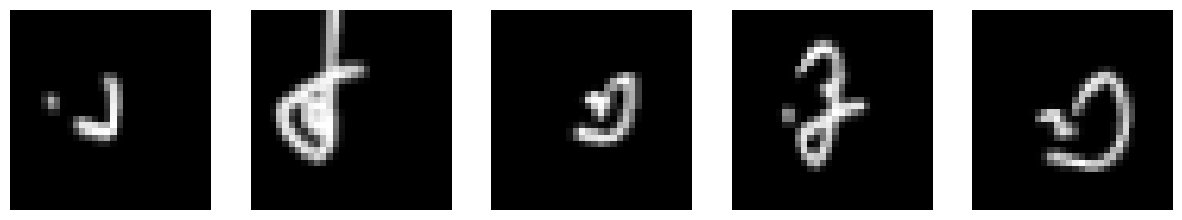

In [36]:
import matplotlib.pyplot as plt

# Example: Get a batch of augmented images
augmented_images = datagen.flow(x_train_final, y_train_final, batch_size=16)

# Plot a few augmented images
fig, axes = plt.subplots(1, 5, figsize=(15, 15))
for i, ax in enumerate(axes):
    ax.imshow(augmented_images[0][0][i].reshape(32, 32), cmap='gray')  # Adjust reshape if needed
    ax.axis('off')
plt.show()


# **CNN Model - Arabic character detection**

In [38]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D ,  Flatten , Dense , MaxPooling2D , Dropout , BatchNormalization , Input , Activation
from tensorflow.keras.layers import Add, Dropout, Flatten, Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [39]:
from tensorflow.keras.models import load_model
# Testing the model we made
model = load_model("early_birds_model_less_complex.h5")

In [40]:
import numpy as np
predictions = model.predict(x_test_reshaped , batch_size= 1)
predictions = np.argmax(predictions,axis = 1)

3360/3360 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step


In [41]:
y_test = np.argmax(y_test_oh, axis=1)

In [42]:
loss , accuracy , _ = model.evaluate(x_test_reshaped , y_test_oh)
print(f"Test loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9814 - f1_score: 0.9774 - loss: 0.7261
Test loss: 0.7162
Test Accuracy: 0.9851


In [43]:
from sklearn.metrics import classification_report , confusion_matrix , ConfusionMatrixDisplay

print(classification_report(y_test , predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      0.99      1.00       120
           2       0.96      0.99      0.98       120
           3       0.98      0.98      0.98       120
           4       0.99      1.00      1.00       120
           5       0.99      0.99      0.99       120
           6       1.00      0.99      1.00       120
           7       0.97      0.97      0.97       120
           8       0.97      0.95      0.96       120
           9       0.94      1.00      0.97       120
          10       0.97      0.94      0.96       120
          11       1.00      0.99      1.00       120
          12       1.00      1.00      1.00       120
          13       0.97      1.00      0.98       120
          14       1.00      0.97      0.98       120
          15       0.96      1.00      0.98       120
          16       1.00      0.96      0.98       120
          17       1.00    

In [44]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 32, 32, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 32, 32, 64)        │             640 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_8         │ (None, 32, 32, 64)        │             256 │ conv2d_9[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_8 (Activation)     │ (None, 32, 32, 64)        │               0 │ batch_normalization_8[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_10 (Conv2D)            │ (None, 32, 32, 64)        │          36,928 │ activation_8[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_9         │ (None, 32, 32, 64)        │             256 │ conv2d_10[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_9 (Activation)     │ (None, 32, 32, 64)        │               0 │ batch_normalization_9[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_11 (Conv2D)            │ (None, 32, 32, 64)        │          36,928 │ activation_9[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_10        │ (None, 32, 32, 64)        │             256 │ conv2d_11[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_3 (Add)                   │ (None, 32, 32, 64)        │               0 │ batch_normalization_10[0]… │
│                               │                           │                 │ activation_8[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_10 (Activation)    │ (None, 32, 32, 64)        │               0 │ add_3[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_3               │ (None, 16, 16, 64)        │               0 │ activation_10[0][0]        │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_4 (Dropout)           │ (None, 16, 16, 64)        │               0 │ max_pooling2d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_13 (Conv2D)            │ (None, 16, 16, 96)        │          55,392 │ dropout_4[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_11        │ (None, 16, 16, 96)        │             38

 Total params: 574,910 (2.19 MB)

 Trainable params: 572,604 (2.18 MB)

 Non-trainable params: 2,304 (9.00 KB)

 Optimizer params: 2 (12.00 B)

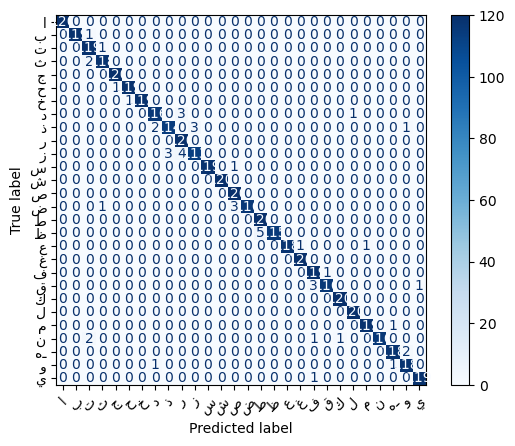

In [45]:
cm = confusion_matrix(y_test , predictions)
ConfusionMatrixDisplay(cm, display_labels=list(label_to_letter.values())).plot(cmap="Blues", xticks_rotation=45)

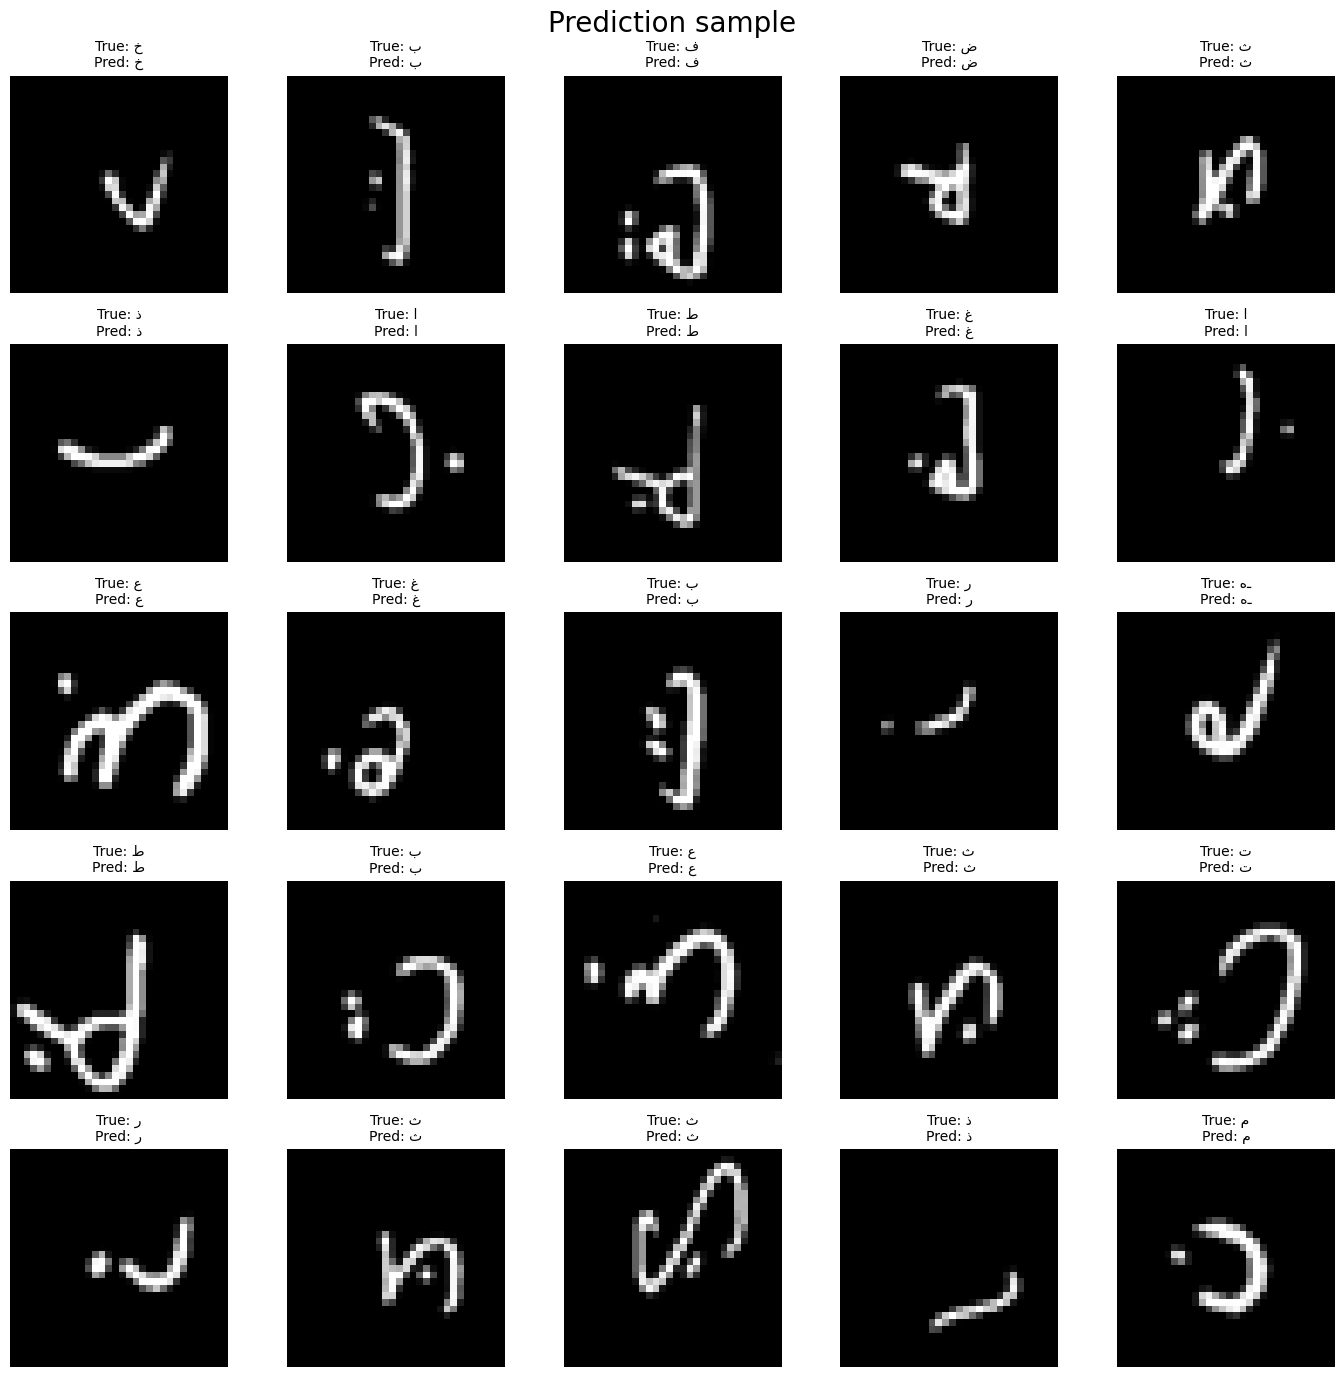

In [46]:
x_test_df = x_test.copy()
x_test_df["true_label"] = pd.Series(y_test).map(label_to_letter)
x_test_df["predicted_label"] = pd.Series(predictions).map(label_to_letter)

random_preds = x_test_df.sample(n=25, random_state=0)  

plt.figure(figsize=(14, 14))
for i, (idx, row) in enumerate(random_preds.iterrows()):
    img = row.iloc[:1024].astype(np.uint8).values.reshape(32, 32)
    true_label = row["true_label"]
    pred_label = row["predicted_label"]
    
    plt.subplot(5, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    plt.axis("off")

plt.suptitle("Prediction sample", fontsize=20)
plt.tight_layout()
plt.show()


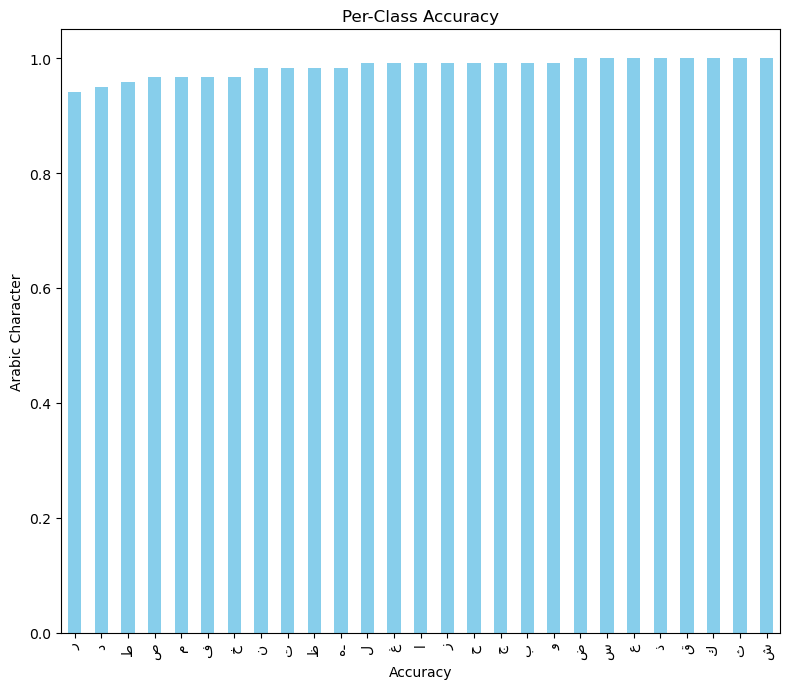

In [47]:
#we add another column to the dataset that holds the boolean value of whether the prediction was correct
#this step is crucial to get the per-class accuracy
x_test_df["correct"] = x_test_df["true_label"] == x_test_df["predicted_label"]

class_accuracy = x_test_df.groupby("true_label")["correct"].mean().sort_values()

plt.figure(figsize=(8, 7))
class_accuracy.plot(kind="bar", color="skyblue")
plt.title("Per-Class Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Arabic Character")
#plt.grid(axis='y')
plt.tight_layout()
plt.show()
